In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


# Importing the Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import AdaBoostClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

# Loading the dataset

In [3]:
train=pd.read_csv('../input/titanic/train.csv')
test=pd.read_csv('../input/titanic/test.csv')

In [4]:
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# Exploratory Data Analysis (EDA)

In [5]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

<AxesSubplot:>

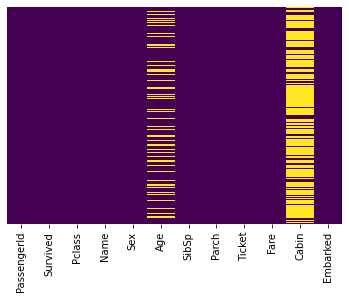

In [6]:
# Visualising the null columns
sns.heatmap(train.isnull(),yticklabels=False,cbar=False,cmap='viridis')

We can observe the Age and cabin data are missing mostly. The Age data is missing 20% roughly. Looking at the cabin column, it looks like we are just missing too much of the data.

<AxesSubplot:xlabel='Survived', ylabel='count'>

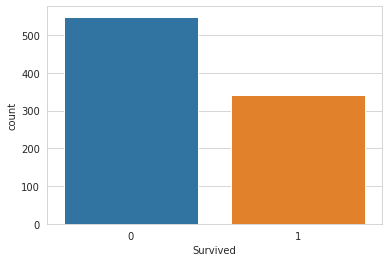

In [7]:
sns.set_style('whitegrid')
sns.countplot(x='Survived',data=train)

<AxesSubplot:xlabel='Sex', ylabel='count'>

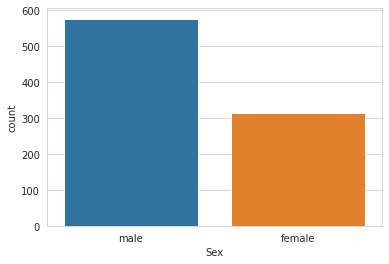

In [8]:
sns.countplot(x='Sex',data=train)

<AxesSubplot:xlabel='Survived', ylabel='count'>

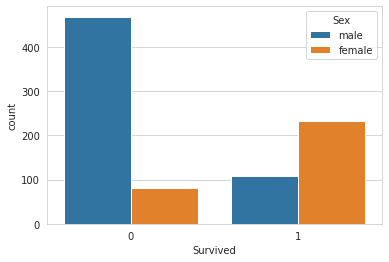

In [9]:
sns.set_style('whitegrid')
sns.countplot(x='Survived',hue='Sex',data=train)

Most of the people survived are female from the sex plot and the hue pot we can conclude more percentage of survival is recorded in females

<AxesSubplot:xlabel='Survived', ylabel='count'>

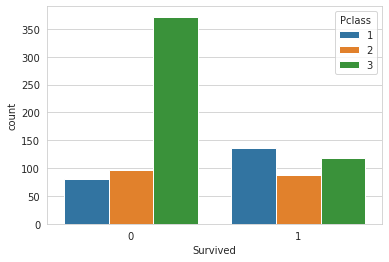

In [10]:
sns.set_style('whitegrid')
sns.countplot(x='Survived',hue='Pclass',data=train)

Most loss occured in passenger class 3 and less loss happened in class 1

<AxesSubplot:xlabel='Age'>

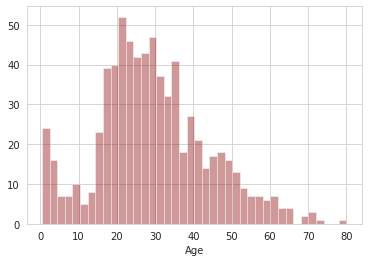

In [11]:
# Understanding the average age of people in titanic
sns.distplot(train['Age'].dropna(),kde=False,color='darkred',bins=40)

Most of the passengers in titanic are aged between 20-30, a very less number of aged people above 65 are attended to titanic

<AxesSubplot:xlabel='SibSp', ylabel='count'>

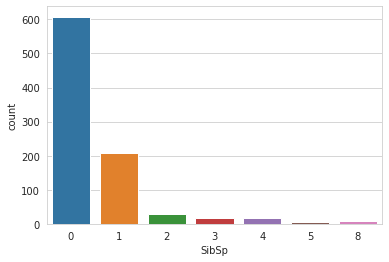

In [12]:
sns.countplot(x='SibSp',data=train)

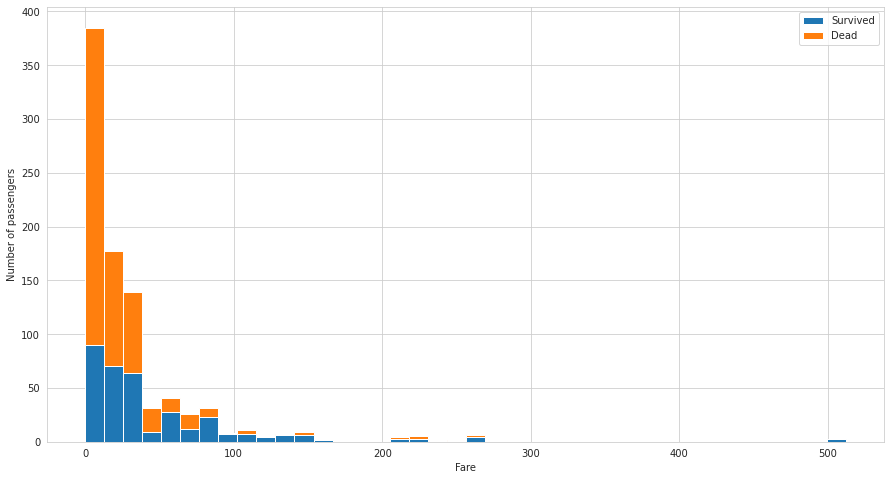

In [13]:
## Visualizing survivals based on fare
figure = plt.figure(figsize=(15, 8))
plt.hist([train[train['Survived'] == 1]['Fare'], train[train['Survived'] == 0]['Fare']], 
         stacked=True, bins = 40, label = ['Survived','Dead'])
plt.xlabel('Fare')
plt.ylabel('Number of passengers')
plt.legend()

<AxesSubplot:xlabel='Pclass', ylabel='Age'>

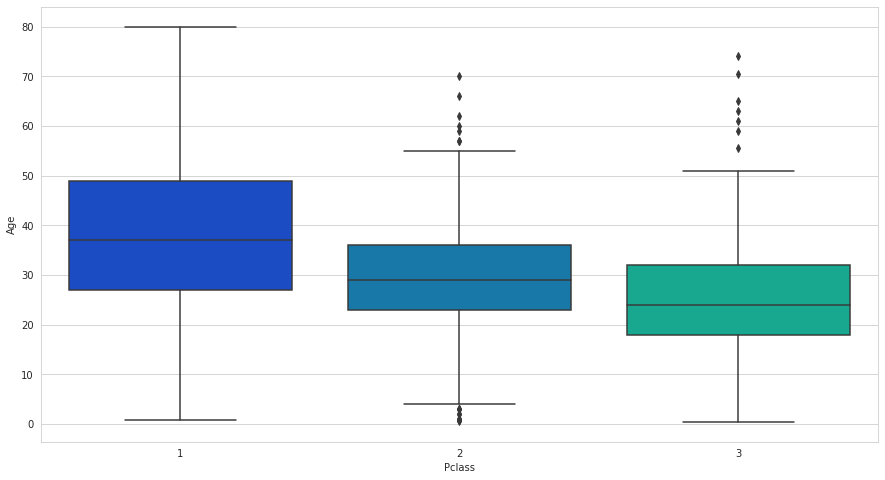

In [14]:
# Checking the average age of passengers in each class
plt.figure(figsize=(15,8))
sns.boxplot(x='Pclass',y='Age',data=train,palette='winter')

In [15]:
# Defining algorithm to fill null values of age
def age(cols):
    
    Age = cols[0]
    Pclass = cols[1]
    
    if pd.isnull(Age):
        
        if Pclass == 1:
            return 37
        
        elif Pclass == 2:
            return 29
        
        else:
            return 24
    
    else:
        return Age

In [16]:
train['Age'] = train[['Age', 'Pclass']].apply(age,axis=1)

<AxesSubplot:>

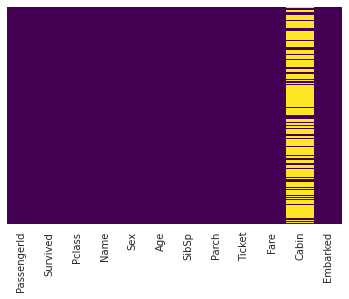

In [17]:
sns.heatmap(train.isnull(),yticklabels=False,cbar=False,cmap='viridis')

Now we can observe only cabin has null values as we replaces the null values of Age with the average age value of the passenger class.

We have a large number of null values in cabin it requires a lot of feature engineering instead of doing feature engineering let we drop this column for now

In [18]:
train.drop('Cabin',axis=1,inplace=True)

In [19]:
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,24.0,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [20]:
train.dropna(inplace=True)

In [21]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 83.3+ KB


In [22]:
train['Name']

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 889, dtype: object

In [23]:
train["Title"] = train["Name"].str.extract('([A-Za-z]+)\.')
test["Title"] = test["Name"].str.extract('([A-Za-z]+)\.')

train["Title"].value_counts()

Mr          517
Miss        181
Mrs         124
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: Title, dtype: int64

In [24]:
def convert_title(title):
    if title in ["Ms", "Mile", "Miss"]:
        return "Miss"
    elif title in ["Mme", "Mrs"]:
        return "Mrs"
    elif title == "Mr":
        return "Mr"
    elif title == "Master":
        return "Master"
    else:
        return "Other"
        
train["Title"] = train["Title"].map(convert_title)
test["Title"] = test["Title"].map(convert_title)

train["Title"].value_counts()

Mr        517
Miss      182
Mrs       125
Master     40
Other      25
Name: Title, dtype: int64

In [25]:
train.drop("Name", axis=1, inplace=True)
test.drop("Name", axis=1, inplace=True)

By adding the values of the SibSp and Parch variables, we can generate a new variable that shows the number of families accompanying their journey. We can then construct a variable that indicates whether or not the passenger is alone from these other data.

In [26]:
data = [train, test]
for df in data:
    df['Relatives'] = df['SibSp'] + df['Parch']
    df.loc[df['Relatives'] > 0, 'Alone'] = 1
    df.loc[df['Relatives'] == 0, 'Alone'] = 0

In [27]:
train

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title,Relatives,Alone
0,1,0,3,male,22.0,1,0,A/5 21171,7.2500,S,Mr,1,1.0
1,2,1,1,female,38.0,1,0,PC 17599,71.2833,C,Mrs,1,1.0
2,3,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss,0,0.0
3,4,1,1,female,35.0,1,0,113803,53.1000,S,Mrs,1,1.0
4,5,0,3,male,35.0,0,0,373450,8.0500,S,Mr,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,211536,13.0000,S,Other,0,0.0
887,888,1,1,female,19.0,0,0,112053,30.0000,S,Miss,0,0.0
888,889,0,3,female,24.0,1,2,W./C. 6607,23.4500,S,Miss,3,1.0
889,890,1,1,male,26.0,0,0,111369,30.0000,C,Mr,0,0.0


In [28]:
train.drop(["SibSp", "Parch"], axis=1, inplace=True)
test.drop(["SibSp", "Parch"], axis=1, inplace=True)

# Converting Categorial Features

In [29]:
sex = pd.get_dummies(train['Sex'],drop_first=True)

In [30]:
embark = pd.get_dummies(train['Embarked'],drop_first=True)

In [31]:
title = pd.get_dummies(train['Title'],drop_first=True)

In [32]:
# removing unwanted columns
train.drop(['PassengerId','Sex','Title','Embarked','Title','Ticket'],axis=1,inplace=True)

In [33]:
train

,Survived,Pclass,Age,Fare,Relatives,Alone
0,0,3,22.0,7.2500,1,1.0
1,1,1,38.0,71.2833,1,1.0
2,1,3,26.0,7.9250,0,0.0
3,1,1,35.0,53.1000,1,1.0
4,0,3,35.0,8.0500,0,0.0
...,...,...,...,...,...,...
886,0,2,27.0,13.0000,0,0.0
887,1,1,19.0,30.0000,0,0.0
888,0,3,24.0,23.4500,3,1.0
889,1,1,26.0,30.0000,0,0.0


In [34]:
train = pd.concat([train,sex,embark,title],axis=1)

In [35]:
train

,Survived,Pclass,Age,Fare,Relatives,Alone,male,Q,S,Miss,Mr,Mrs,Other
0,0,3,22.0,7.2500,1,1.0,1,0,1,0,1,0,0
1,1,1,38.0,71.2833,1,1.0,0,0,0,0,0,1,0
2,1,3,26.0,7.9250,0,0.0,0,0,1,1,0,0,0
3,1,1,35.0,53.1000,1,1.0,0,0,1,0,0,1,0
4,0,3,35.0,8.0500,0,0.0,1,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,13.0000,0,0.0,1,0,1,0,0,0,1
887,1,1,19.0,30.0000,0,0.0,0,0,1,1,0,0,0
888,0,3,24.0,23.4500,3,1.0,0,0,1,1,0,0,0
889,1,1,26.0,30.0000,0,0.0,1,0,0,0,1,0,0


# Building a Logistic Regression model

In [36]:
train.drop('Survived',axis=1).head()

,Pclass,Age,Fare,Relatives,Alone,male,Q,S,Miss,Mr,Mrs,Other
0,3,22.0,7.2500,1,1.0,1,0,1,0,1,0,0
1,1,38.0,71.2833,1,1.0,0,0,0,0,0,1,0
2,3,26.0,7.9250,0,0.0,0,0,1,1,0,0,0
3,1,35.0,53.1000,1,1.0,0,0,1,0,0,1,0
4,3,35.0,8.0500,0,0.0,1,0,1,0,1,0,0


In [37]:
train.replace([np.inf, -np.inf], np.nan, inplace=True)

In [38]:
train.dropna(inplace=True)

In [39]:
train.isnull().sum()

Survived     0
Pclass       0
Age          0
Fare         0
Relatives    0
Alone        0
male         0
Q            0
S            0
Miss         0
Mr           0
Mrs          0
Other        0
dtype: int64

In [40]:
train.dtypes

Survived       int64
Pclass         int64
Age          float64
Fare         float64
Relatives      int64
Alone        float64
male           uint8
Q              uint8
S              uint8
Miss           uint8
Mr             uint8
Mrs            uint8
Other          uint8
dtype: object

In [41]:
# Feature scaling to standardize the values for age and fare
train.Age = (train.Age-min(train.Age))/(max(train.Age)-min(train.Age))
train.Fare = (train.Fare-min(train.Fare))/(max(train.Fare)-min(train.Fare))

In [42]:
train

,Survived,Pclass,Age,Fare,Relatives,Alone,male,Q,S,Miss,Mr,Mrs,Other
0,0,3,0.271174,0.014151,1,1.0,1,0,1,0,1,0,0
1,1,1,0.472229,0.139136,1,1.0,0,0,0,0,0,1,0
2,1,3,0.321438,0.015469,0,0.0,0,0,1,1,0,0,0
3,1,1,0.434531,0.103644,1,1.0,0,0,1,0,0,1,0
4,0,3,0.434531,0.015713,0,0.0,1,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,0.334004,0.025374,0,0.0,1,0,1,0,0,0,1
887,1,1,0.233476,0.058556,0,0.0,0,0,1,1,0,0,0
888,0,3,0.296306,0.045771,3,1.0,0,0,1,1,0,0,0
889,1,1,0.321438,0.058556,0,0.0,1,0,0,0,1,0,0


In [43]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(train.drop('Survived', axis=1),
                                                   train['Survived'], test_size=0.35,
                                                   random_state=0,stratify=train.Survived)

In [44]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training the Model

In [45]:
logmodel = LogisticRegression()
logmodel.fit(X_train,y_train)

LogisticRegression()

In [46]:
predictions = logmodel.predict(X_test)

In [47]:
accuracy = confusion_matrix(y_test,predictions)

In [48]:
accuracy

array([[175,  18],
       [ 28,  91]])

In [49]:
accuracy_score(y_test,predictions)

0.8525641025641025

In [50]:
classifier = RandomForestClassifier()
classifier.fit(X_train,y_train)

RandomForestClassifier()

In [51]:
y_pred = classifier.predict(X_test)

In [52]:
confusion_matrix(y_test,y_pred)

array([[168,  25],
       [ 33,  86]])

In [53]:
accuracy_score(y_test,y_pred)

0.8141025641025641

In [54]:
model1=AdaBoostClassifier(n_estimators=100, random_state=0)
# Fitting the Model
model1.fit(X_train,y_train)

AdaBoostClassifier(n_estimators=100, random_state=0)

In [55]:
adaClassify = model1.predict(X_test)
confusion_matrix(y_test,adaClassify)

array([[164,  29],
       [ 25,  94]])

In [56]:
accuracy_score(y_test,adaClassify)

0.8269230769230769

In [57]:
from sklearn.model_selection import cross_validate, GridSearchCV
lr = LogisticRegression()
params = {
    "penalty": ("l1", "l2", "elasticnet"),
    "tol": (0.1, 0.01, 0.001, 0.0001),
    "C": (10.0, 1.0, 0.1, 0.01)
}
clf = GridSearchCV(lr, params, cv=10)
clf.fit(X_train, y_train)
print("Best hyperparameter:", clf.best_params_)

Best hyperparameter: {'C': 10.0, 'penalty': 'l2', 'tol': 0.1}


Train Accuracy: 0.830155979202773


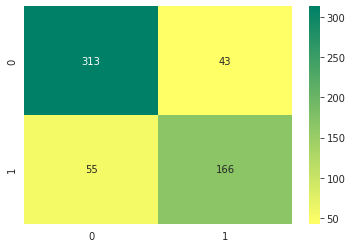

In [58]:
y_pred2 = clf.predict(X_train)
print(f"Train Accuracy: {accuracy_score(y_train, y_pred2)}")
sns.heatmap(confusion_matrix(y_train, y_pred2), fmt='.3g', annot=True, cmap='summer_r')
plt.show()

# Processing test data

In [59]:
test

,PassengerId,Pclass,Sex,Age,Ticket,Fare,Cabin,Embarked,Title,Relatives,Alone
0,892,3,male,34.5,330911,7.8292,NaN,Q,Mr,0,0.0
1,893,3,female,47.0,363272,7.0000,NaN,S,Mrs,1,1.0
2,894,2,male,62.0,240276,9.6875,NaN,Q,Mr,0,0.0
3,895,3,male,27.0,315154,8.6625,NaN,S,Mr,0,0.0
4,896,3,female,22.0,3101298,12.2875,NaN,S,Mrs,2,1.0
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,male,NaN,A.5. 3236,8.0500,NaN,S,Mr,0,0.0
414,1306,1,female,39.0,PC 17758,108.9000,C105,C,Other,0,0.0
415,1307,3,male,38.5,SOTON/O.Q. 3101262,7.2500,NaN,S,Mr,0,0.0
416,1308,3,male,NaN,359309,8.0500,NaN,S,Mr,0,0.0


In [60]:
test_df=test.drop(['PassengerId','Ticket','Cabin'], axis=1)
test_df

,Pclass,Sex,Age,Fare,Embarked,Title,Relatives,Alone
0,3,male,34.5,7.8292,Q,Mr,0,0.0
1,3,female,47.0,7.0000,S,Mrs,1,1.0
2,2,male,62.0,9.6875,Q,Mr,0,0.0
3,3,male,27.0,8.6625,S,Mr,0,0.0
4,3,female,22.0,12.2875,S,Mrs,2,1.0
...,...,...,...,...,...,...,...,...
413,3,male,NaN,8.0500,S,Mr,0,0.0
414,1,female,39.0,108.9000,C,Other,0,0.0
415,3,male,38.5,7.2500,S,Mr,0,0.0
416,3,male,NaN,8.0500,S,Mr,0,0.0


In [61]:
sex = pd.get_dummies(test_df['Sex'],drop_first=True)
embark = pd.get_dummies(test_df['Embarked'],drop_first=True)
title = pd.get_dummies(test_df['Title'],drop_first=True)

In [62]:
test_df.drop(['Sex','Embarked','Title'],axis=1,inplace=True)

In [63]:
test_df = pd.concat([test_df,sex,embark,title],axis=1)

In [64]:
test_df['Age'] = test_df[['Age', 'Pclass']].apply(age,axis=1)

In [65]:
test_df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [66]:
# Feature scaling to standardize the values for age and fare
test_df.Age = (test_df.Age-min(test_df.Age))/(max(test_df.Age)-min(test_df.Age))
test_df.Fare = (test_df.Fare-min(test_df.Fare))/(max(test_df.Fare)-min(test_df.Fare))

In [67]:
test_df

,Pclass,Age,Fare,Relatives,Alone,male,Q,S,Miss,Mr,Mrs,Other
0,3,0.452723,0.015282,0,0.0,1,1,0,0,1,0,0
1,3,0.617566,0.013663,1,1.0,0,0,1,0,0,1,0
2,2,0.815377,0.018909,0,0.0,1,1,0,0,1,0,0
3,3,0.353818,0.016908,0,0.0,1,0,1,0,1,0,0
4,3,0.287881,0.023984,2,1.0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
413,3,0.314256,0.015713,0,0.0,1,0,1,0,1,0,0
414,1,0.512066,0.212559,0,0.0,0,0,0,0,0,0,1
415,3,0.505473,0.014151,0,0.0,1,0,1,0,1,0,0
416,3,0.314256,0.015713,0,0.0,1,0,1,0,1,0,0


In [68]:
test_df['Fare']=test_df['Fare'].fillna(test_df['Fare'].mean())

In [69]:
test_df.isnull().sum()

Pclass       0
Age          0
Fare         0
Relatives    0
Alone        0
male         0
Q            0
S            0
Miss         0
Mr           0
Mrs          0
Other        0
dtype: int64

In [70]:
pred = classifier.predict(test_df)
pred

array([0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,

In [71]:
pred1 = logmodel.predict(test_df)
pred1

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [72]:
pred2 = model1.predict(test_df)
pred2

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [73]:
pred3 = clf.predict(test_df)
pred3

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [74]:
submission = pd.read_csv("../input/titanic/gender_submission.csv")
submission["Survived"] = pred1
submission.to_csv('submission.csv', index=False)
# submission = pd.DataFrame({"PassengerId": test["PassengerId"], "Survived": pred1})
# submission.to_csv('submission.csv', index=False)

In [75]:
prediction_data = pd.read_csv('submission.csv')

<AxesSubplot:xlabel='Survived', ylabel='count'>

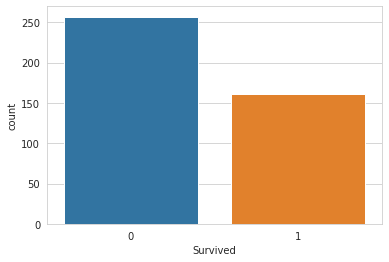

In [76]:
#Visualizing predicted values
sns.countplot(x='Survived', data=prediction_data)